In [2]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, brier_score_loss
)

# Interpretability
import shap

# Settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

print("All imports successful")

All imports successful


In [3]:
df = pd.read_csv('heart_disease_processed.csv')
print(df.shape)
print(df.head())
print(df.isnull().sum())

(920, 12)
    age  sex   cp  trestbps   chol  fbs  restecg  thalch  exang  oldpeak  \
0  63.0  1.0  3.0     145.0  233.0  1.0      0.0   150.0    0.0      2.3   
1  67.0  1.0  0.0     160.0  286.0  0.0      0.0   108.0    1.0      1.5   
2  67.0  1.0  0.0     120.0  229.0  0.0      0.0   129.0    1.0      2.6   
3  37.0  1.0  2.0     130.0  250.0  0.0      1.0   187.0    0.0      3.5   
4  41.0  0.0  1.0     130.0  204.0  0.0      0.0   172.0    0.0      1.4   

   slope  target  
0    0.0     0.0  
1    1.0     1.0  
2    1.0     1.0  
3    0.0     0.0  
4    2.0     0.0  
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
target      0
dtype: int64


In [4]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Hold-out set: 20% reserved for final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # maintains class distribution
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass distribution in test set:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (736, 11)
Test set: (184, 11)

Class distribution in training set:
target
1.0    0.553
0.0    0.447
Name: proportion, dtype: float64

Class distribution in test set:
target
1.0    0.554
0.0    0.446
Name: proportion, dtype: float64


## Scaling Strategy

**StandardScaler** was applied to normalize all features to mean=0 
and standard deviation=1, but only for models that require it.

**Why Logistic Regression needs scaling:**
Logistic Regression assigns a coefficient (weight) to each feature. 
If `age` ranges from 28-77 and `exang` ranges from 0-1, the model 
may assign a disproportionately large coefficient to `exang` simply 
because its values are small — not because it is more important. 
Scaling ensures all features are on the same scale so coefficients 
are comparable and meaningful.

**Why tree-based models do NOT need scaling:**
Random Forest and XGBoost make decisions based on thresholds — 
"if age > 55, go right". The threshold adjusts automatically 
regardless of the feature's scale. Scaling has no effect on 
tree-based model performance.

| Model | Scaling Required |
|-------|-----------------|
| Logistic Regression |  Yes — StandardScaler applied |
| Decision Tree |  No |
| Random Forest |  No |
| XGBoost |  No |

**Implementation note:** The scaler was fit **only on the training set** 
(`fit_transform`) and then applied to the test set (`transform`). 
Fitting on the full dataset would constitute data leakage — the model 
would have indirect knowledge of the test set distribution.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression w/ Stratified K-Fold

In [6]:
# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)

# Cross-validate
lr_scores = cross_validate(
    lr, X_train_scaled, y_train,
    cv=cv,
    scoring=['roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=True
)

print("Logistic Regression — Cross-Validation Results:")
print(f"ROC-AUC:   {lr_scores['test_roc_auc'].mean():.3f} ± {lr_scores['test_roc_auc'].std():.3f}")
print(f"F1:        {lr_scores['test_f1'].mean():.3f} ± {lr_scores['test_f1'].std():.3f}")
print(f"Precision: {lr_scores['test_precision'].mean():.3f} ± {lr_scores['test_precision'].std():.3f}")
print(f"Recall:    {lr_scores['test_recall'].mean():.3f} ± {lr_scores['test_recall'].std():.3f}")

Logistic Regression — Cross-Validation Results:
ROC-AUC:   0.868 ± 0.016
F1:        0.823 ± 0.017
Precision: 0.824 ± 0.031
Recall:    0.825 ± 0.037


## Evaluation Metrics

### ROC-AUC (Receiver Operating Characteristic — Area Under Curve)
Measures how well the model separates CAD from no-CAD patients 
across all possible classification thresholds. 

- **0.5** = random guessing (no discrimination)
- **1.0** = perfect separation
- **>0.8** = considered strong for clinical prediction models

### F1-Score
Harmonic mean of Precision and Recall. Useful when both false 
positives and false negatives carry clinical cost.
F1 = 2 × (Precision × Recall) / (Precision + Recall)

### Precision
Of all patients the model predicted as CAD-positive, 
what fraction actually had CAD?
Precision = True Positives / (True Positives + False Positives)

High precision = few false alarms → fewer unnecessary procedures.

### Recall (Sensitivity)
Of all patients who actually had CAD, what fraction did 
the model correctly identify?
Recall = True Positives / (True Positives + False Negatives)

High recall = few missed cases → fewer undetected diseases.

### The Clinical Tradeoff
In cardiovascular disease prediction, **recall is prioritized** 
over precision — missing a true CAD case (false negative) can 
delay life-saving treatment, while a false positive leads to 
additional non-invasive testing. Both matter, but the cost 
of a false negative is higher.

### Consistency (± std)
The ± value after each metric represents the standard deviation 
across the 5 K-Fold splits. A small ± indicates the model 
performs consistently regardless of which patients end up in 
each fold — a sign of a robust model.

In [7]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt_scores = cross_validate(
    dt, X_train, y_train,
    cv=cv,
    scoring=['roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=False
)

print("Decision Tree — Cross-Validation Results:")
print(f"ROC-AUC:   {dt_scores['test_roc_auc'].mean():.3f} ± {dt_scores['test_roc_auc'].std():.3f}")
print(f"F1:        {dt_scores['test_f1'].mean():.3f} ± {dt_scores['test_f1'].std():.3f}")
print(f"Precision: {dt_scores['test_precision'].mean():.3f} ± {dt_scores['test_precision'].std():.3f}")
print(f"Recall:    {dt_scores['test_recall'].mean():.3f} ± {dt_scores['test_recall'].std():.3f}")

Decision Tree — Cross-Validation Results:
ROC-AUC:   0.737 ± 0.014
F1:        0.762 ± 0.020
Precision: 0.770 ± 0.022
Recall:    0.757 ± 0.050


In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf_scores = cross_validate(
    rf, X_train, y_train,
    cv=cv,
    scoring=['roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=False
)

print("Random Forest — Cross-Validation Results:")
print(f"ROC-AUC:   {rf_scores['test_roc_auc'].mean():.3f} ± {rf_scores['test_roc_auc'].std():.3f}")
print(f"F1:        {rf_scores['test_f1'].mean():.3f} ± {rf_scores['test_f1'].std():.3f}")
print(f"Precision: {rf_scores['test_precision'].mean():.3f} ± {rf_scores['test_precision'].std():.3f}")
print(f"Recall:    {rf_scores['test_recall'].mean():.3f} ± {rf_scores['test_recall'].std():.3f}")

Random Forest — Cross-Validation Results:
ROC-AUC:   0.882 ± 0.025
F1:        0.847 ± 0.021
Precision: 0.838 ± 0.043
Recall:    0.857 ± 0.010


In [9]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

xgb_scores = cross_validate(
    xgb, X_train, y_train,
    cv=cv,
    scoring=['roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=False
)

print("XGBoost — Cross-Validation Results:")
print(f"ROC-AUC:   {xgb_scores['test_roc_auc'].mean():.3f} ± {xgb_scores['test_roc_auc'].std():.3f}")
print(f"F1:        {xgb_scores['test_f1'].mean():.3f} ± {xgb_scores['test_f1'].std():.3f}")
print(f"Precision: {xgb_scores['test_precision'].mean():.3f} ± {xgb_scores['test_precision'].std():.3f}")
print(f"Recall:    {xgb_scores['test_recall'].mean():.3f} ± {xgb_scores['test_recall'].std():.3f}")

XGBoost — Cross-Validation Results:
ROC-AUC:   0.868 ± 0.030
F1:        0.829 ± 0.022
Precision: 0.820 ± 0.046
Recall:    0.840 ± 0.027


In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1  # usa todos los cores
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best ROC-AUC: {grid_search.best_score_:.3f}")

Best params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Best ROC-AUC: 0.895


In [11]:
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}

grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)

print(f"Best params: {grid_search_xgb.best_params_}")
print(f"Best ROC-AUC: {grid_search_xgb.best_score_:.3f}")

Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Best ROC-AUC: 0.885


In [12]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Random Forest — Hold-out Test Set Results:")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}")
print(f"F1:        {f1_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

Random Forest — Hold-out Test Set Results:
ROC-AUC:   0.920
F1:        0.859
Precision: 0.854
Recall:    0.863

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.82      0.82        82
         1.0       0.85      0.86      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [13]:
print(f"False negatives: {102 - round(102 * 0.86)}")

False negatives: 14


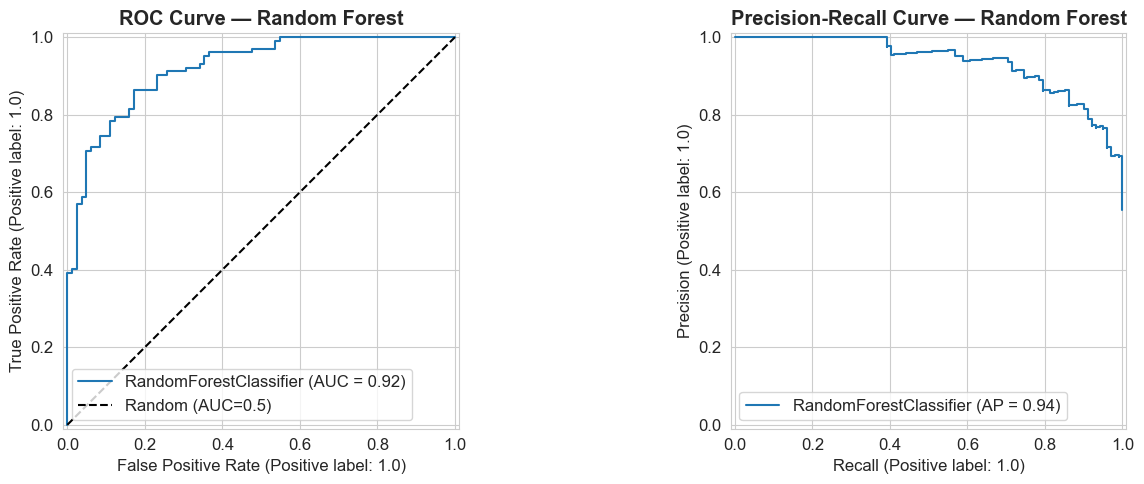

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=axes[0])
axes[0].set_title('ROC Curve — Random Forest', fontweight='bold')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[0].legend()

# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(best_rf, X_test, y_test, ax=axes[1])
axes[1].set_title('Precision-Recall Curve — Random Forest', fontweight='bold')

plt.tight_layout()
plt.show()

## Confusion Matrix

A confusion matrix summarizes model predictions against actual diagnoses, 
showing True Positives, True Negatives, False Positives, and False Negatives. 
In clinical context, **False Negatives** (CAD patients predicted as healthy) 
are the most critical error — they represent missed diagnoses.

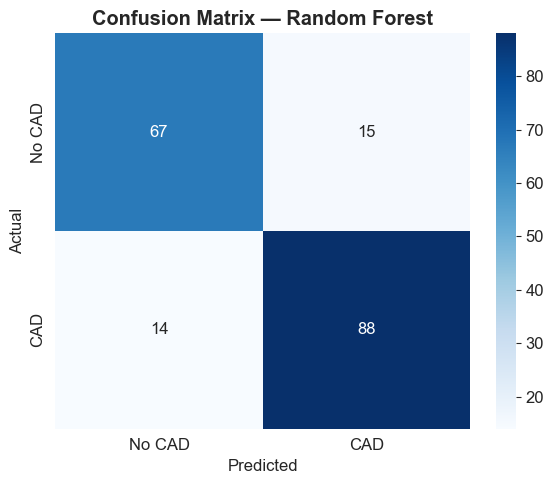

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CAD', 'CAD'],
            yticklabels=['No CAD', 'CAD'],
            ax=ax)

ax.set_title('Confusion Matrix — Random Forest', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [18]:
# SHAP explainer for Random Forest
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

print(type(shap_values))
print(len(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
184
(184, 11, 2)


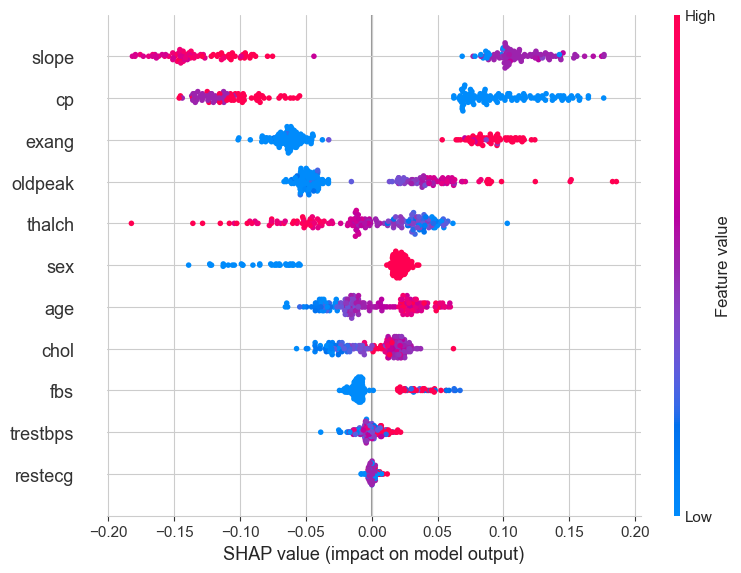

In [19]:
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X_test.columns.tolist())

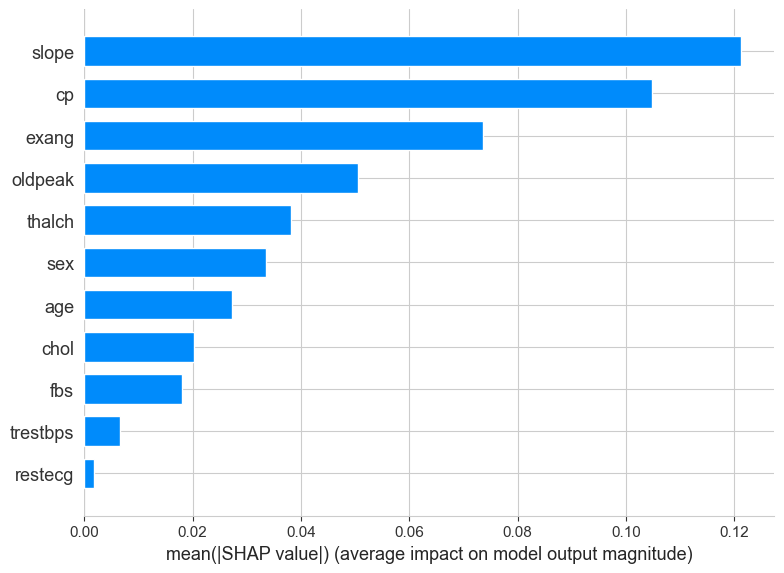

In [20]:
shap.summary_plot(shap_values[:, :, 1], X_test, 
                  feature_names=X_test.columns.tolist(),
                  plot_type='bar')

## SHAP Analysis — Feature Importance

### Global Feature Importance (Bar Plot)
The SHAP bar plot reveals the average impact of each feature 
on model predictions, confirming and refining the EDA-based 
feature ranking.

**Key finding:** `slope` emerged as the strongest predictor 
(mean |SHAP| = 0.12), surpassing its EDA rank of 5th. This is 
partly explained by the iterative imputation with 309 missing 
values filled, the model had access to complete `slope` data for 
all 920 patients, allowing it to learn a stronger pattern than 
was visible in the univariate analysis.

The top 5 features are all directly or indirectly related to 
exercise stress testing:
- `slope` — ST segment direction during exercise
- `cp` — chest pain type (asymptomatic referral = high clinical suspicion)
- `exang` — exercise induced angina
- `oldpeak` — ST depression magnitude during exercise
- `thalch` — maximum heart rate achieved

This confirms the central finding of the EDA: **physiological 
response under stress is more informative than resting measurements 
for CAD prediction.**

**General risk factors** (`age`, `sex`) show moderate importance 
(mean |SHAP| = 0.03–0.04), consistent with their EDA assessment 
epidemiologically relevant but not directly measuring cardiac function.

**Weak predictors** (`trestbps`, `restecg`) show minimal SHAP values 
(<0.01), validating the EDA finding that resting measurements 
overlap heavily between disease and no-disease groups.

### Beeswarm Plot
The beeswarm plot adds directionality to the importance ranking:
- High `slope` values (flat/downsloping) push predictions toward CAD
- Low `cp` values (asymptomatic) push toward CAD — confirming the 
  counterintuitive EDA finding
- High `exang` (True) pushes toward CAD
- Low `thalch` (reduced exercise capacity) pushes toward CAD


In [21]:
# Get sex from original dataframe using the same indices
sex_test = df.iloc[X_test.index]['sex'] if 'sex' in df.columns else None

# Check what values we have
print(X_test['sex'].value_counts())

sex
1.0    149
0.0     35
Name: count, dtype: int64


In [22]:
# Split test set by sex
male_mask = X_test['sex'] == 1.0
female_mask = X_test['sex'] == 0.0

# Male metrics
y_test_male = y_test[male_mask]
y_pred_male = best_rf.predict(X_test[male_mask])
y_prob_male = best_rf.predict_proba(X_test[male_mask])[:, 1]

# Female metrics
y_test_female = y_test[female_mask]
y_pred_female = best_rf.predict(X_test[female_mask])
y_prob_female = best_rf.predict_proba(X_test[female_mask])[:, 1]

print("=== MALE ===")
print(f"ROC-AUC:   {roc_auc_score(y_test_male, y_prob_male):.3f}")
print(f"F1:        {f1_score(y_test_male, y_pred_male):.3f}")
print(f"Recall:    {recall_score(y_test_male, y_pred_male):.3f}")
print(f"Precision: {precision_score(y_test_male, y_pred_male):.3f}")

print("\n=== FEMALE ===")
print(f"ROC-AUC:   {roc_auc_score(y_test_female, y_prob_female):.3f}")
print(f"F1:        {f1_score(y_test_female, y_pred_female):.3f}")
print(f"Recall:    {recall_score(y_test_female, y_pred_female):.3f}")
print(f"Precision: {precision_score(y_test_female, y_pred_female):.3f}")

=== MALE ===
ROC-AUC:   0.911
F1:        0.878
Recall:    0.883
Precision: 0.874

=== FEMALE ===
ROC-AUC:   0.917
F1:        0.625
Recall:    0.625
Precision: 0.625


In [24]:
print(f"Female CAD cases in test: {y_test_female.sum()}")
print(f"Female no-CAD cases in test: {(y_test_female == 0).sum()}")

Female CAD cases in test: 8.0
Female no-CAD cases in test: 27


## Fairness Evaluation — Performance by Sex

| Metric | Male (n=149) | Female (n=35) |
|--------|-------------|---------------|
| ROC-AUC | 0.911 | 0.917 |
| F1 | 0.878 | 0.625 |
| Recall | 0.883 | 0.625 |
| Precision | 0.874 | 0.625 |

Both groups achieve strong ROC-AUC (>0.91), indicating the model 
can discriminate between CAD and no-CAD in both sexes. However, 
F1, Recall, and Precision drop substantially for female patients 
(0.625 vs 0.878).

**Two factors explain this gap:**

1. **Insufficient female data:** Only 35 female patients in the 
   hold-out set, with just 8 CAD-positive cases. The model correctly 
   identified 5 of 8 — a single additional miss would drop recall 
   to 0.50. Metrics at this sample size are statistically unreliable.

2. **Training imbalance:** The full dataset contains 726 male vs 
   194 female patients (79% vs 21%). The model learned predominantly 
   from male presentation patterns. CAD in women often presents 
   atypically — fewer stress-test-induced symptoms, more non-anginal 
   chest pain — patterns underrepresented in this dataset.

**Clinical implication:** This model should not be used as a 
standalone screening tool for female patients without further 
validation on a larger, sex-balanced dataset.

**Future work:** Collecting more female patient data and applying 
fairness-aware training techniques (e.g. reweighting, stratified 
sampling) would be necessary before clinical deployment.